In [1]:
import scanpy as sc
from ma_package.spatial_mapping import map_points_to_regions_from_anndata
from geopandas import read_parquet
import pandas as pd
import os
from tqdm import tqdm
from joblib import Parallel, delayed
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from cellseg_benchmark._constants import method_colors
from pathlib import Path
import matplotlib as mpl
from collections import defaultdict
from scipy.stats import pearsonr

In [2]:
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Liberation Sans", "Arial", "DejaVu Sans"],
    "font.size": 10,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
})

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
def process_algo(algo, adata_int_path, regions_by_slide):
    adata_tmp = sc.read_h5ad(
        os.path.join(adata_int_path, algo, "adatas", "adata_integrated.h5ad.gz")
    )

    mapped = map_points_to_regions_from_anndata(
        adata_tmp,
        regions_by_slide=regions_by_slide,
        coord_key="spatial_microns",
        slide_key="sample",
        include_boundary=True,
        dissolve=False,
        index_kind="name",
        return_df=True,
    )

    df_all = pd.concat([v["df"] for v in mapped.values()], ignore_index=True)
    df_all = df_all.set_index("obs_id").reindex(adata_tmp.obs_names)

    adata_tmp.obs["anatom_region"] = df_all["label"].values
    adata_tmp.obs["region_poly_index"] = df_all["poly_index"].values

    counts_samp_reg_ct = (
        adata_tmp.obs
        .groupby(["sample", "anatom_region", "cell_type_revised"])
        .agg(cell_count_reg_ct=("anatom_region", "size"), volume_sum=("volume_final", "sum"))
        .reset_index()
    )

    counts_samp_reg = (
        adata_tmp.obs
        .groupby(["sample", "anatom_region"])
        .agg(cell_count_reg=("anatom_region", "size"))
        .reset_index()
    )

    age = adata_tmp.obs[["sample", "age_months"]].drop_duplicates()

    merged = (
        counts_samp_reg
        .merge(counts_samp_reg_ct, on=["sample", "anatom_region"])
        .merge(age, on="sample")
    )

    merged["proportion"] = merged["cell_count_reg_ct"] / merged["cell_count_reg"]
    merged["method"] = algo

    return merged


def subset_regions(df, regions=None, celltypes=None, algorithms=None):
    if regions is None:
        regions = list(df['anatom_region'].unique())
    elif not isinstance(regions, list):
        regions = [regions]
    if celltypes is None:
        celltypes = list(df['cell_type_revised'])
    elif not isinstance(celltypes, list):
        celltypes = [celltypes]
    if algorithms is None:
        algorithms = list(df["method"].unique())
    elif not isinstance(algorithms, list):
        algorithms = [algorithms]

    mask_reg = df['anatom_region'].isin(regions)
    mask_ct = df['cell_type_revised'].isin(celltypes)
    mask_algo = df['method'].isin(algorithms)
    mask = mask_reg & mask_ct & mask_algo
    df_tmp = df[mask]
    df_tmp['method'] = df_tmp['method'].cat.remove_unused_categories()
    df_tmp['cell_type_revised'] = df_tmp['cell_type_revised'].cat.remove_unused_categories()

    vol = (df_tmp.groupby(["sample", "anatom_region", "method"])
           .agg(area_mm2_sum=("area_mm2_sum", "first"))
           .reset_index()
           .groupby(["sample", "method"])
           .agg(area_mm2_sum=("area_mm2_sum","sum"))
           .reset_index()
          )
    ct_count = (df_tmp.groupby(["sample", "anatom_region", "method"])
           .agg(cell_count_sum=("cell_count_reg", "first"))
           .reset_index()
           .groupby(["sample", "method"])
           .agg(cell_count_sum=("cell_count_sum","sum"))
           .reset_index()
          )
    df_res = (df_tmp.groupby(["sample", "cell_type_revised", "method"])
              .agg(cell_count_reg_ct = ("cell_count_reg_ct", "sum"), volume_sum=("volume_sum","sum"))
              .reset_index()
             )
    df_age = df_tmp[["sample", "age_months"]].drop_duplicates()
    df_res = df_res.merge(vol, on=["sample", "method"]).merge(ct_count, on=["sample", "method"])
    df_res = df_res.merge(df_age, on="sample")
    df_res["cell_counts_per_mm2"] = df_res["cell_count_reg_ct"]/df_res["area_mm2_sum"]
    df_res["cell_counts_rel"] = df_res["cell_count_reg_ct"]/df_res["cell_count_sum"]
    return df_res

In [5]:
region_annot_path = "/dss/dsshome1/00/ra87rib/cellseg-benchmark/misc/brain_regions/aging_brain_regions.parquet"
adata_int_path = "/dss/dsshome1/00/ra87rib/cellseg-benchmark/analysis/aging"
out_path = Path("/dss/dsshome1/00/ra87rib/260607_daten_bilder_MA")

In [6]:
anatom_annot = read_parquet(region_annot_path)
result = {}

for subj, gdf_subj in anatom_annot.groupby("sample"):   # or whatever your subject column is called
    inner = {}
    for region, gdf_region in gdf_subj.groupby("label"):  # e.g. HIP, CTX, STR, ...
        inner[region] = list(gdf_region.geometry)  # or the column that holds your polygons
    result[subj] = inner

In [7]:
anatom_annot['area'] = anatom_annot['geometry'].area
anatom_annot['area_mm2'] = anatom_annot['geometry'].area*1e-6
anatom_annot_grouped = anatom_annot.groupby(["sample", "label"]).agg(area_sum=("area", "sum"), area_mm2_sum=("area_mm2", "sum"))

In [8]:
algos = os.listdir(adata_int_path)

res_tables = Parallel(n_jobs=-1)(
    delayed(process_algo)(algo, adata_int_path, result) for algo in tqdm(algos)
)

  0%|          | 0/35 [00:00<?, ?it/s]/tmp/ipykernel_461048/3418226054.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/tmp/ipykernel_461048/3418226054.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
 29%|██▊       | 10/35 [01:44<04:21, 10.48s/it]/tmp/ipykernel_461048/3418226054.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/tmp/ipykernel_461048/3418226054.py:32: FutureWarning: The default of observed=False is

In [9]:
merged_all = pd.concat(res_tables)
for _, a in merged_all[["sample", "anatom_region"]].drop_duplicates().iterrows():
    mask_sample = merged_all['sample'] == a['sample']
    mask_reg = merged_all['anatom_region'] == a['anatom_region']
    mask = mask_sample & mask_reg
    try:
        merged_all.loc[mask, 'area_mm2_sum'] = anatom_annot_grouped.loc[a['sample'], a['anatom_region']]['area_mm2_sum']
    except KeyError as e:
        if all(merged_all.loc[mask, 'cell_count_reg'] == 0):
            merged_all.loc[mask, 'area_mm2_sum'] = 0
        else:
            raise KeyError(e)
merged_all['cell_counts_per_mm2'] = merged_all['cell_count_reg_ct']/merged_all['area_mm2_sum']
merged_all['area_covered'] = merged_all['volume_sum']*1e-6/merged_all['area_mm2_sum']
merged_all = merged_all.reindex()
merged_all['method'] = merged_all['method'].astype("category")
merged_all["cell_type_revised"] = merged_all["cell_type_revised"].astype("category")
merged_all

,sample,anatom_region,cell_count_reg,cell_type_revised,cell_count_reg_ct,volume_sum,age_months,proportion,method,area_mm2_sum,cell_counts_per_mm2,area_covered
0,aging_s1_r1,BS,9250,ECs,973,1.808000e+06,6,0.105189,Proseg_3D_Cellpose_1_nuclei_model,5.390046,180.517927,0.335433
1,aging_s1_r1,BS,9250,Pericytes,313,6.419393e+05,6,0.033838,Proseg_3D_Cellpose_1_nuclei_model,5.390046,58.070001,0.119097
2,aging_s1_r1,BS,9250,SMCs,150,2.949451e+05,6,0.016216,Proseg_3D_Cellpose_1_nuclei_model,5.390046,27.829074,0.054720
3,aging_s1_r1,BS,9250,VLMCs,36,6.361200e+04,6,0.003892,Proseg_3D_Cellpose_1_nuclei_model,5.390046,6.678978,0.011802
4,aging_s1_r1,BS,9250,ABCs,0,0.000000e+00,6,0.000000,Proseg_3D_Cellpose_1_nuclei_model,5.390046,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
4411,aging_s12_r0,fiber_tracts,9169,Neurons-Dopa,201,2.841821e+05,12,0.021922,Baysor_2D_Cellpose_1_DAPI_PolyT_0.8,2.515344,79.909543,0.112979
4412,aging_s12_r0,fiber_tracts,9169,Neurons-Granule-Immature,1,1.346788e+02,12,0.000109,Baysor_2D_Cellpose_1_DAPI_PolyT_0.8,2.515344,0.397560,0.000054
4413,aging_s12_r0,fiber_tracts,9169,Neurons-Other,16,3.194225e+04,12,0.001745,Baysor_2D_Cellpose_1_DAPI_PolyT_0.8,2.515344,6.360959,0.012699
4414,aging_s12_r0,fiber_tracts,9169,OECs,0,0.000000e+00,12,0.000000,Baysor_2D_Cellpose_1_DAPI_PolyT_0.8,2.515344,0.000000,0.000000


In [10]:
merged_all.to_excel(out_path / "Comp_ana_all.xlsx")

In [10]:
method_colors["Proseg_3D_Cellpose_1_DAPI_PolyT"] = "#d1c9b4"
method_colors["Proseg_3D_Cellpose_1_DAPI_Transcripts"] = "#d6c9a9"
method_colors

{'Baysor_2D_Cellpose_1_DAPI_PolyT_0.2': '#9a0013',
 'Baysor_2D_Cellpose_1_DAPI_PolyT_0.8': '#a71423',
 'Baysor_2D_Cellpose_1_DAPI_Transcripts_0.2': '#b32833',
 'Baysor_2D_Cellpose_1_DAPI_Transcripts_0.8': '#c03b43',
 'Baysor_2D_Cellpose_1_nuclei_model_1.0': '#cc4f53',
 'Baysor_2D_Cellpose_2_DAPI_PolyT_0.2': '#d96363',
 'Baysor_2D_Cellpose_2_DAPI_PolyT_0.8': '#e67673',
 'Baysor_2D_Cellpose_2_DAPI_Transcripts_0.2': '#f28a83',
 'Baysor_2D_Cellpose_2_DAPI_Transcripts_0.8': '#ff9e93',
 'vpt_2D_DAPI_PolyT': '#08306b',
 'vpt_2D_DAPI_PolyT_nuclei': '#08519c',
 'vpt_2D_DAPI_nuclei': '#2171b5',
 'vpt_2D_DAPI_watershed': '#4292c6',
 'vpt_3D_DAPI_PolyT': '#6baed6',
 'vpt_3D_DAPI_PolyT_nuclei': '#9ecae1',
 'vpt_3D_DAPI_nuclei': '#a9d5f1',
 'vpt_p3D_watershed_DAPI_PolyT': '#8cc9e9',
 'vpt_p3D_watershed_DAPI_PolyT_gaussian': '#70bde1',
 'vpt_watershed_DAPI_PolyT_z3': '#52b3da',
 'Cellpose_1_nuclei_model': '#00441b',
 'Cellpose_1_DAPI_PolyT': '#006d2c',
 'Cellpose_1_DAPI_Transcripts': '#217a37',
 'Cel

In [11]:
methods = [x for x in os.listdir("/dss/dssfs03/pn52re/pn52re-dss-0001/cellseg-benchmark/analysis/aging") if not x.startswith("Negative") and x not in ["SIS_DAPI_total_mrna", "Watershed_Merlin"]]
methods.sort()
methods

['Baysor_2D_Cellpose_1_DAPI_PolyT_0.2',
 'Baysor_2D_Cellpose_1_DAPI_PolyT_0.8',
 'Baysor_2D_Cellpose_1_DAPI_Transcripts_0.2',
 'Baysor_2D_Cellpose_1_DAPI_Transcripts_0.8',
 'Baysor_2D_Cellpose_1_nuclei_model_1.0',
 'Baysor_2D_Cellpose_2_DAPI_PolyT_0.2',
 'Baysor_2D_Cellpose_2_DAPI_PolyT_0.8',
 'Baysor_2D_Cellpose_2_DAPI_Transcripts_0.2',
 'Baysor_2D_Cellpose_2_DAPI_Transcripts_0.8',
 'Cellpose_1_DAPI_PolyT',
 'Cellpose_1_DAPI_Transcripts',
 'Cellpose_1_Merlin',
 'Cellpose_1_nuclei_model',
 'Cellpose_2_DAPI_PolyT',
 'Cellpose_2_DAPI_Transcripts',
 'Proseg_3D_Cellpose_1_DAPI_PolyT',
 'Proseg_3D_Cellpose_1_DAPI_Transcripts',
 'Proseg_3D_Cellpose_1_nuclei_model',
 'Proseg_3D_Cellpose_2_DAPI_PolyT',
 'Proseg_3D_Cellpose_2_DAPI_Transcripts',
 'Proseg_3D_vpt3D_DAPI_PolyT',
 'Proseg_3D_vpt3D_DAPI_PolyT_nuclei',
 'Proseg_3D_vpt3D_DAPI_nuclei',
 'vpt_2D_DAPI_PolyT',
 'vpt_2D_DAPI_PolyT_nuclei',
 'vpt_2D_DAPI_nuclei',
 'vpt_3D_DAPI_PolyT',
 'vpt_3D_DAPI_PolyT_nuclei',
 'vpt_3D_DAPI_nuclei']

In [42]:
sample_vols = anatom_annot.groupby("sample").agg(area_total=("area","sum")).reset_index()
sample_vols['volume']  = sample_vols['area_total']*7*1.5
tot_cell_vols = subset_regions(merged_all, None, None, methods).groupby(["method", "sample"]).agg(cells_vol_total=("volume_sum", "sum"))
res = sample_vols.merge(tot_cell_vols.reset_index(), on="sample")
res['%_covered'] = res['cells_vol_total']/res['volume']
res = res[res['cells_vol_total']!=0]
res

,sample,area_total,volume,method,cells_vol_total,%_covered
0,aging_s10_r0,2.411171e+07,2.531729e+08,Baysor_2D_Cellpose_1_DAPI_PolyT_0.2,2.237974e+08,0.883970
1,aging_s10_r0,2.411171e+07,2.531729e+08,Baysor_2D_Cellpose_1_DAPI_PolyT_0.8,2.173011e+08,0.858311
2,aging_s10_r0,2.411171e+07,2.531729e+08,Baysor_2D_Cellpose_1_DAPI_Transcripts_0.2,2.303358e+08,0.909796
3,aging_s10_r0,2.411171e+07,2.531729e+08,Baysor_2D_Cellpose_1_DAPI_Transcripts_0.8,2.007067e+08,0.792765
4,aging_s10_r0,2.411171e+07,2.531729e+08,Baysor_2D_Cellpose_1_nuclei_model_1.0,2.274655e+08,0.898459
...,...,...,...,...,...,...
459,aging_s8_r2,3.001905e+07,3.152000e+08,vpt_2D_DAPI_PolyT_nuclei,1.350218e+08,0.428368
460,aging_s8_r2,3.001905e+07,3.152000e+08,vpt_2D_DAPI_nuclei,6.766496e+07,0.214673
461,aging_s8_r2,3.001905e+07,3.152000e+08,vpt_3D_DAPI_PolyT,2.148779e+07,0.068172
462,aging_s8_r2,3.001905e+07,3.152000e+08,vpt_3D_DAPI_PolyT_nuclei,4.657616e+07,0.147767


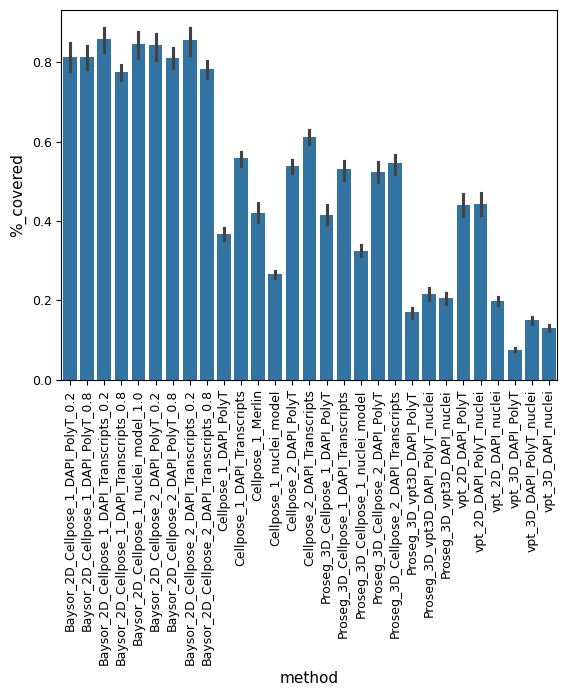

In [45]:
sns.barplot(res, x="method", y="%_covered")
plt.xticks(rotation=90)
plt.savefig(out_path / f"samples_coverage.png")
plt.savefig(out_path / f"samples_coverage.pdf")
plt.savefig(out_path / f"samples_coverage.svg")

In [13]:
sns.set_style("whitegrid")

<Figure size 2000x1000 with 0 Axes>

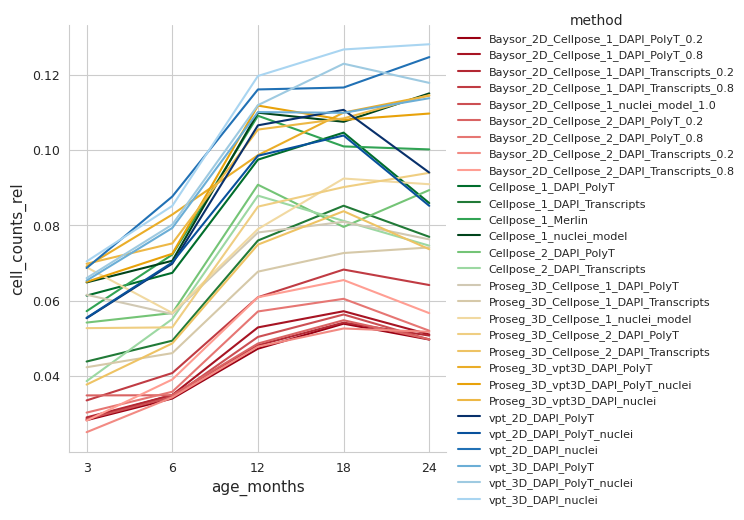

<Figure size 2000x1000 with 0 Axes>

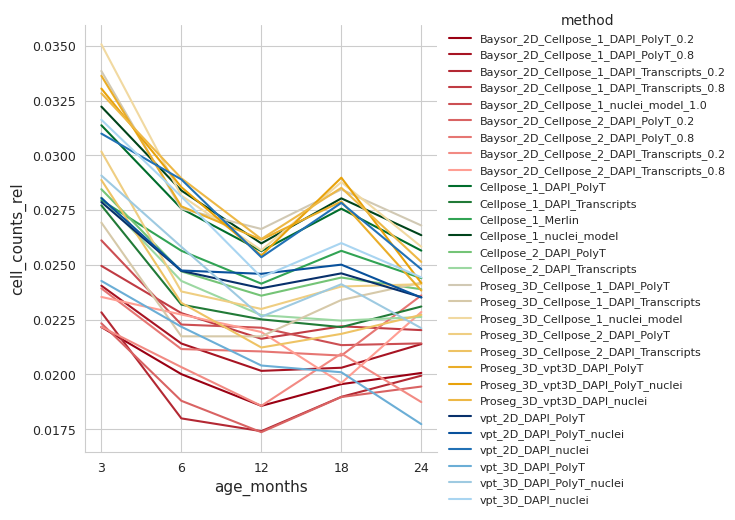

<Figure size 2000x1000 with 0 Axes>

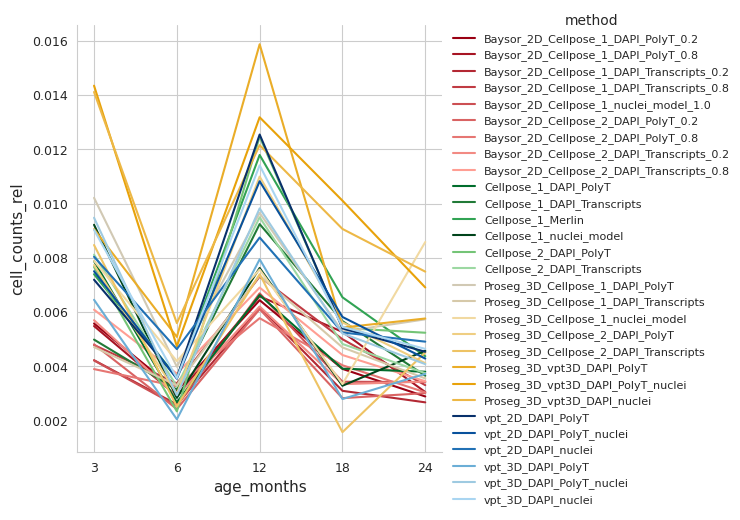

<Figure size 2000x1000 with 0 Axes>

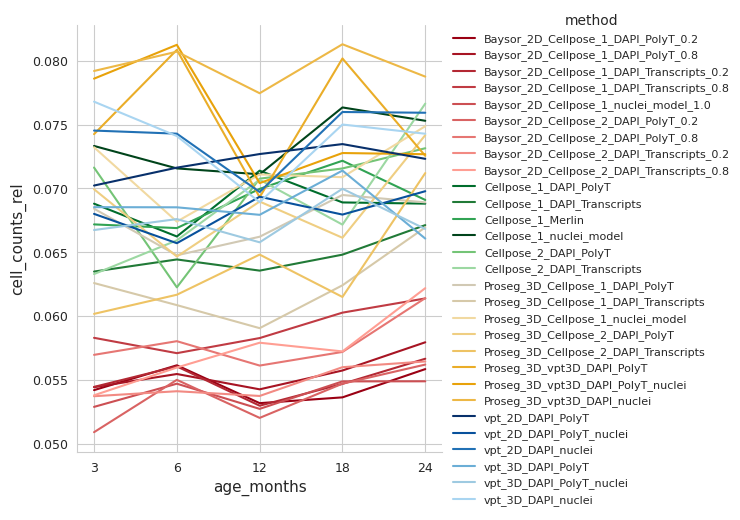

<Figure size 2000x1000 with 0 Axes>

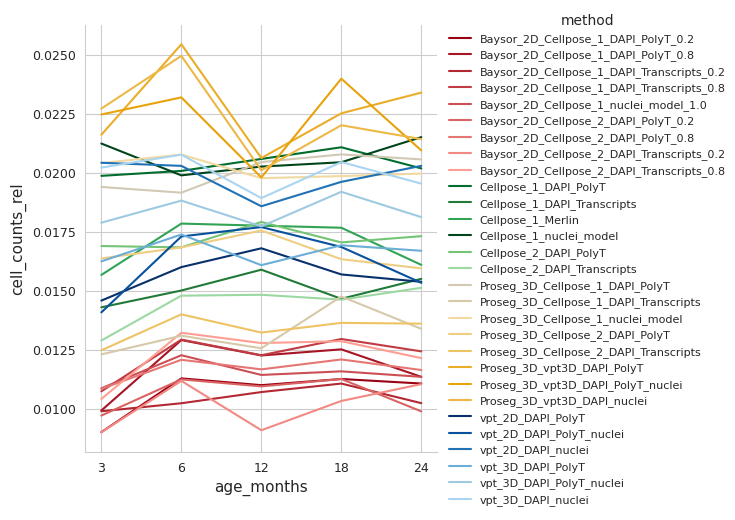

<Figure size 2000x1000 with 0 Axes>

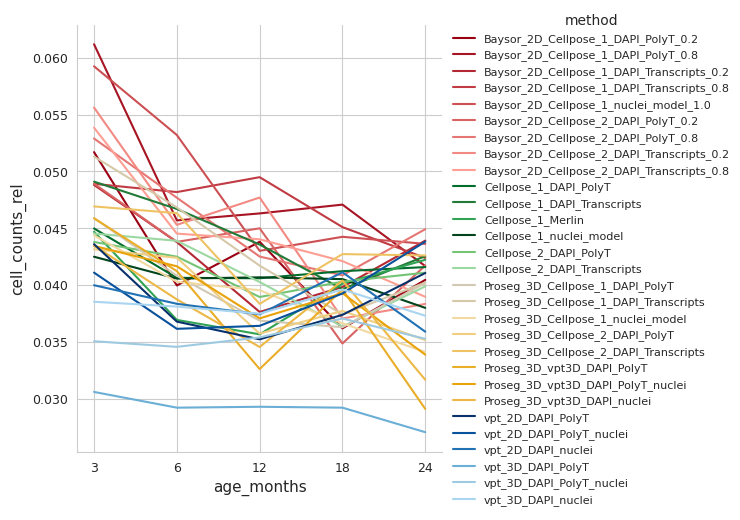

<Figure size 2000x1000 with 0 Axes>

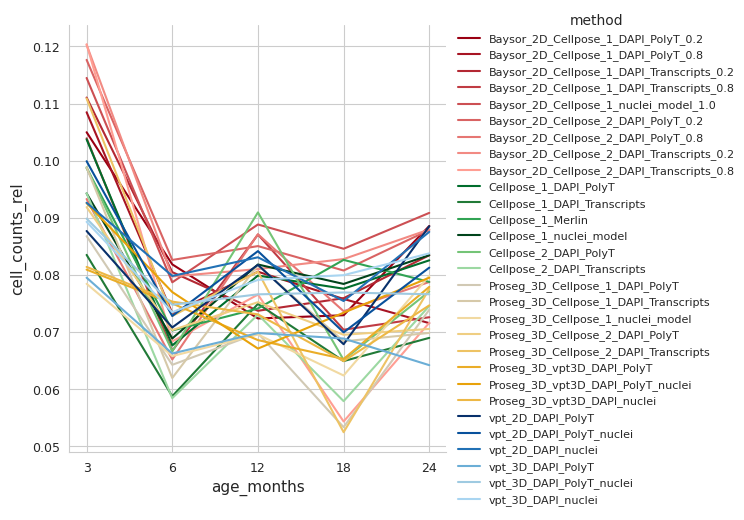

In [18]:
for cell_type in ["Oligodendrocytes", "OPCs", "VLMCs", "ECs", "Pericytes", "Microglia", "Astrocytes"]:
    data = subset_regions(merged_all, ["CTX", "STR/CTX", "STR"], cell_type, methods)
    data.to_excel(out_path / f"Comp_ana_CTX_STR_{cell_type}.xlsx")
    plt.figure(figsize=(20, 10))
    sns.relplot(
        data=data,
        x="age_months",
        y="cell_counts_rel",
        hue="method",
        kind="line",
        estimator="mean",
        palette = method_colors,
        ci=None
    )
    #plt.tight_layout()
    plt.savefig(out_path / f"Comp_ana_CTX_STR_{cell_type}_rel.png")
    plt.savefig(out_path / f"Comp_ana_CTX_STR_{cell_type}_rel.pdf")
    plt.savefig(out_path / f"Comp_ana_CTX_STR_{cell_type}_rel.svg")

<Figure size 2000x1000 with 0 Axes>

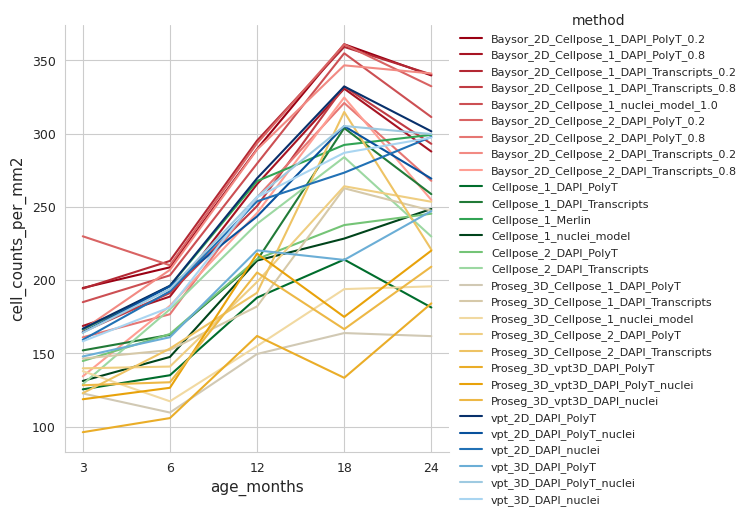

<Figure size 2000x1000 with 0 Axes>

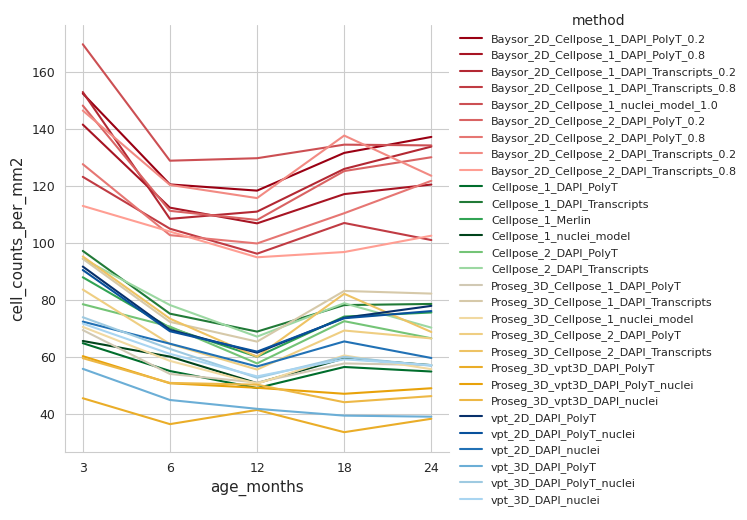

<Figure size 2000x1000 with 0 Axes>

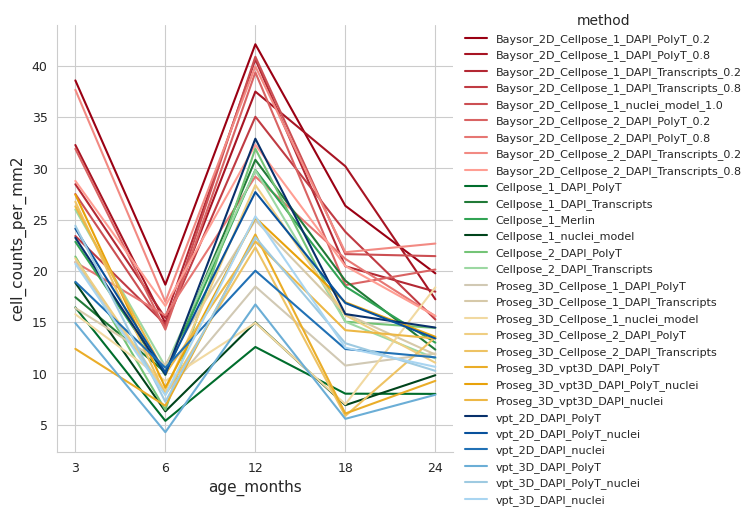

<Figure size 2000x1000 with 0 Axes>

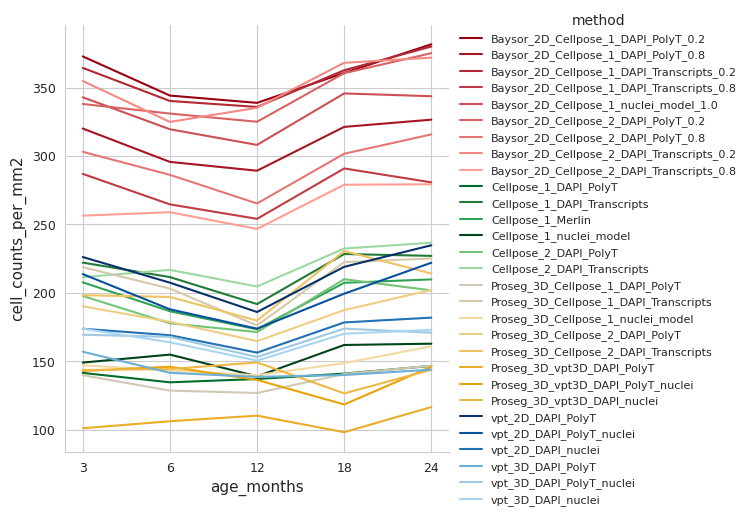

<Figure size 2000x1000 with 0 Axes>

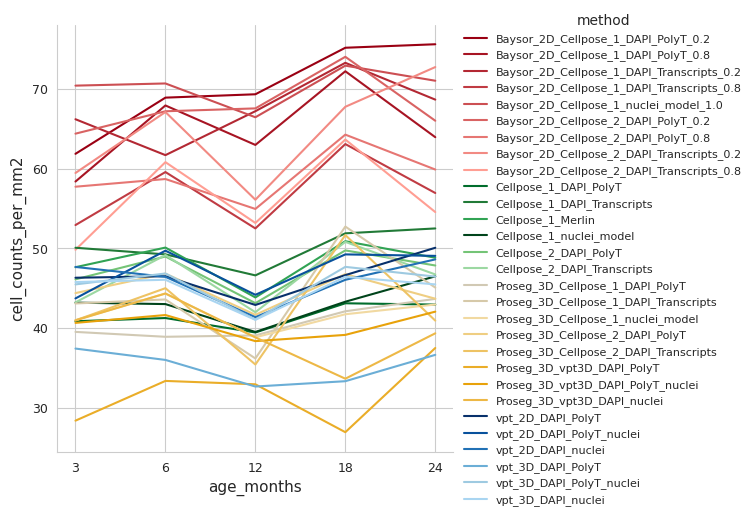

<Figure size 2000x1000 with 0 Axes>

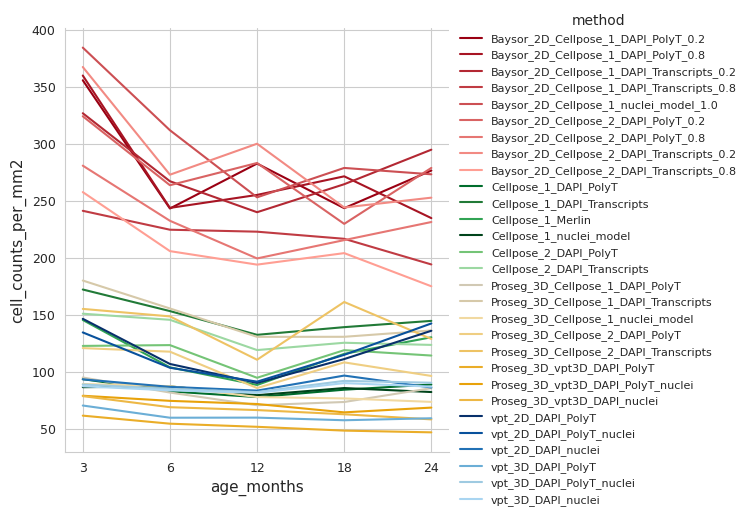

<Figure size 2000x1000 with 0 Axes>

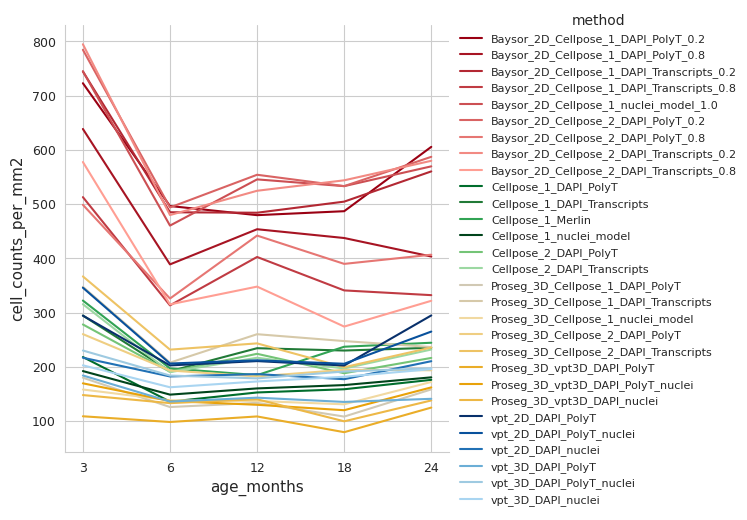

In [14]:
for cell_type in ["Oligodendrocytes", "OPCs", "VLMCs", "ECs", "Pericytes", "Microglia", "Astrocytes"]:
    data = subset_regions(merged_all, ["CTX", "STR/CTX", "STR"], cell_type, methods)
    data.to_excel(out_path / f"Comp_ana_CTX_STR_{cell_type}.xlsx")
    plt.figure(figsize=(20, 10))
    sns.relplot(
        data=data,
        x="age_months",
        y="cell_counts_per_mm2",
        hue="method",
        kind="line",
        estimator="mean",
        palette = method_colors,
        ci=None
    )
    #plt.tight_layout()
    plt.savefig(out_path / f"Comp_ana_CTX_STR_{cell_type}.png")
    plt.savefig(out_path / f"Comp_ana_CTX_STR_{cell_type}.pdf")
    plt.savefig(out_path / f"Comp_ana_CTX_STR_{cell_type}.svg")

# Test for general trend (e.g. signif. increase change to 3m)

In [13]:
for cell_type in ["Oligodendrocytes", "OPCs", "VLMCs", "ECs", "Pericytes", "Microglia", "Astrocytes"]:
    slope_3_24 = subset_regions(merged_all, ["CTX", "STR/CTX", "STR"], cell_type, methods)
    slope_3_24_agg = (
        slope_3_24[["cell_counts_per_mm2", "age_months", "method"]].groupby(["method", "age_months"])
          .mean()
          .reset_index()
    )
    slope_3_24_agg = slope_3_24_agg.pivot(index="method", columns="age_months", values="cell_counts_per_mm2")
    slope_3_24_agg["delta_24_3"] = slope_3_24_agg["24"] - slope_3_24_agg["3"]
    slope_3_24_agg["delta_18_3"] = slope_3_24_agg["18"] - slope_3_24_agg["3"]
    t_tests_18 = {}
    t_tests_24 = {}
    for method in methods:
        mask_method = slope_3_24['method'] == method
        mask_age_3 = slope_3_24['age_months'] == "3"
        mask_age_24 = slope_3_24['age_months'] == "24"
        mask_24 = mask_method & (mask_age_3 | mask_age_24)
        mask_age_18 = slope_3_24['age_months'] == "18"
        mask_18 = mask_method & (mask_age_3 | mask_age_18)
        tmp = slope_3_24[mask_24]
        tmp.dropna(inplace=True)
        t_tests_24[method] = ttest_ind(tmp.loc[tmp['age_months']=="3", "cell_counts_per_mm2"], tmp.loc[tmp['age_months']=="24", "cell_counts_per_mm2"])
        tmp = slope_3_24[mask_18]
        tmp.dropna(inplace=True)
        t_tests_18[method] = ttest_ind(tmp.loc[tmp['age_months']=="3", "cell_counts_per_mm2"], tmp.loc[tmp['age_months']=="18", "cell_counts_per_mm2"])
    ((pd.DataFrame(t_tests_18, index=["t_stat_18", "pvalue_18"]).T)
     .merge(pd.DataFrame(t_tests_24, index=["t_stat_24", "pvalue_24"]).T, left_index=True, right_index=True)
     .merge(slope_3_24_agg, left_index=True, right_index=True)
    ).to_excel(out_path / f"Comp_ana_CTX_STR_{cell_type}_ttest.xlsx")

# Corr prior (Proseg and Baysor)

In [12]:
pairs = {
    "Baysor_2D_Cellpose_1_DAPI_PolyT_0.2": "Cellpose_1_DAPI_PolyT", 
    "Baysor_2D_Cellpose_1_DAPI_PolyT_0.8":"Cellpose_1_DAPI_PolyT",
    "Baysor_2D_Cellpose_2_DAPI_PolyT_0.2": "Cellpose_2_DAPI_PolyT",
    "Baysor_2D_Cellpose_2_DAPI_PolyT_0.8": "Cellpose_2_DAPI_PolyT",
    "Baysor_2D_Cellpose_1_DAPI_Transcripts_0.2": "Cellpose_1_DAPI_Transcripts",
    "Baysor_2D_Cellpose_1_DAPI_Transcripts_0.8": "Cellpose_1_DAPI_Transcripts",
    "Baysor_2D_Cellpose_2_DAPI_Transcripts_0.2": "Cellpose_2_DAPI_Transcripts",
    "Baysor_2D_Cellpose_2_DAPI_Transcripts_0.8": "Cellpose_2_DAPI_Transcripts",
    "Baysor_2D_Cellpose_1_nuclei_model_1.0": "Cellpose_1_nuclei_model",
    "Proseg_3D_Cellpose_1_DAPI_PolyT": "Cellpose_1_DAPI_PolyT",
    "Proseg_3D_Cellpose_1_DAPI_Transcripts": "Cellpose_1_DAPI_Transcripts",
    "Proseg_3D_Cellpose_1_nuclei_model": "Cellpose_1_nuclei_model",
    "Proseg_3D_Cellpose_2_DAPI_PolyT": "Cellpose_2_DAPI_PolyT",
    "Proseg_3D_Cellpose_2_DAPI_Transcripts": "Cellpose_2_DAPI_Transcripts",
    "Proseg_3D_vpt3D_DAPI_PolyT": "vpt_3D_DAPI_PolyT",
    "Proseg_3D_vpt3D_DAPI_PolyT_nuclei": "vpt_3D_DAPI_PolyT_nuclei",
    "Proseg_3D_vpt3D_DAPI_nuclei": "vpt_3D_DAPI_nuclei"
}

In [13]:
total_counts = (merged_all[["method", "anatom_region", "cell_count_reg"]]
                .drop_duplicates()
                .groupby(["method"])
                .agg(sum_counts=("cell_count_reg", "sum"))
                .reset_index()
               )
df = defaultdict(list)
for seg, prior in pairs.items():
    df['prior_segmentation'].append(prior)
    df['segmentation'].append(seg)
    df['prior_counts'].append(total_counts.loc[total_counts['method']==prior, "sum_counts"].values[0])
    df['segmentation_counts'].append(total_counts.loc[total_counts['method']==seg, "sum_counts"].values[0])
corr_df = pd.DataFrame(df)
corr_df['segmentation'] = corr_df['segmentation'].astype("category")
corr_df['segmentation'] = corr_df['segmentation'].cat.reorder_categories([
    "Baysor_2D_Cellpose_1_DAPI_PolyT_0.2",
    "Baysor_2D_Cellpose_1_DAPI_PolyT_0.8",
    "Baysor_2D_Cellpose_1_DAPI_Transcripts_0.2",
    "Baysor_2D_Cellpose_1_DAPI_Transcripts_0.8",
    "Baysor_2D_Cellpose_1_nuclei_model_1.0",
    "Baysor_2D_Cellpose_2_DAPI_PolyT_0.2",
    "Baysor_2D_Cellpose_2_DAPI_PolyT_0.8",
    "Baysor_2D_Cellpose_2_DAPI_Transcripts_0.2",
    "Baysor_2D_Cellpose_2_DAPI_Transcripts_0.8",
    "Proseg_3D_Cellpose_1_DAPI_PolyT",
    "Proseg_3D_Cellpose_1_DAPI_Transcripts",
    "Proseg_3D_Cellpose_1_nuclei_model",
    "Proseg_3D_Cellpose_2_DAPI_PolyT",
    "Proseg_3D_Cellpose_2_DAPI_Transcripts",
    "Proseg_3D_vpt3D_DAPI_PolyT",
    "Proseg_3D_vpt3D_DAPI_PolyT_nuclei",
    "Proseg_3D_vpt3D_DAPI_nuclei"
])
corr_df

,prior_segmentation,segmentation,prior_counts,segmentation_counts
0,Cellpose_1_DAPI_PolyT,Baysor_2D_Cellpose_1_DAPI_PolyT_0.2,723607,2368636
1,Cellpose_1_DAPI_PolyT,Baysor_2D_Cellpose_1_DAPI_PolyT_0.8,723607,2049785
2,Cellpose_2_DAPI_PolyT,Baysor_2D_Cellpose_2_DAPI_PolyT_0.2,1049550,2318679
3,Cellpose_2_DAPI_PolyT,Baysor_2D_Cellpose_2_DAPI_PolyT_0.8,1049550,1856947
4,Cellpose_1_DAPI_Transcripts,Baysor_2D_Cellpose_1_DAPI_Transcripts_0.2,1298768,2360300
5,Cellpose_1_DAPI_Transcripts,Baysor_2D_Cellpose_1_DAPI_Transcripts_0.8,1298768,1776944
6,Cellpose_2_DAPI_Transcripts,Baysor_2D_Cellpose_2_DAPI_Transcripts_0.2,1150490,2155803
7,Cellpose_2_DAPI_Transcripts,Baysor_2D_Cellpose_2_DAPI_Transcripts_0.8,1150490,1596501
8,Cellpose_1_nuclei_model,Baysor_2D_Cellpose_1_nuclei_model_1.0,703813,2235587
9,Cellpose_1_DAPI_PolyT,Proseg_3D_Cellpose_1_DAPI_PolyT,723607,720428


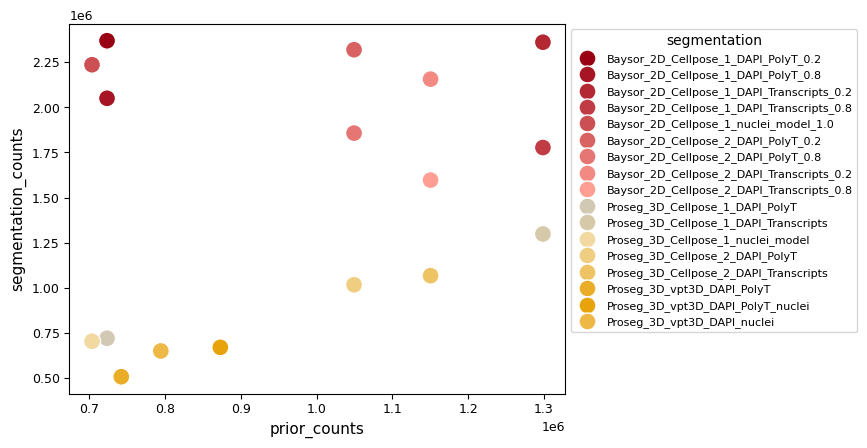

In [17]:
ax = sns.scatterplot(corr_df, x="prior_counts", y="segmentation_counts", hue="segmentation", palette=method_colors, s=150)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig(out_path / f"corr_prior_counts.png")
plt.savefig(out_path / f"corr_prior_counts.pdf")
plt.savefig(out_path / f"corr_prior_counts.svg")

In [28]:
tmp = corr_df[["Baysor" in x for x in corr_df['segmentation']]]
pearsonr(tmp['segmentation_counts'], tmp['prior_counts'])

PearsonRResult(statistic=np.float64(-0.34225358180625404), pvalue=np.float64(0.36728990926704824))

In [29]:
tmp = corr_df[["Proseg" in x for x in corr_df['segmentation']]]
pearsonr(tmp['segmentation_counts'], tmp['prior_counts'])

PearsonRResult(statistic=np.float64(0.9401316338486948), pvalue=np.float64(0.0005126546391447373))